# Two-class priority queueing models — simulation, exact analysis, comparison

A working notebook for the thesis. We define a master model with seven
parameters $(\lambda_1, \lambda_2, \mu, \gamma_1, \gamma_2, \theta_1, \theta_2)$ and
recover each studied variant by choosing them appropriately:

| variant | $\gamma_1$ | $\gamma_2$ | $\theta_1$ | $\theta_2$ |
|---|---|---|---|---|
| Model A | 0 | 0 | 0 | 0 |
| Model B | $\geq 0$ | $\geq 0$ | 0 | 0 |
| Model B-1 | 0 | $\geq 0$ | 0 | 0 |
| Model B-2 | $\geq 0$ | 0 | 0 | 0 |
| Abandonments | $\geq 0$ | $\geq 0$ | $\geq 0$ | $\geq 0$ |
| **Special case (this notebook)** | 0 | 0 | $> 0$ | 0 |

The state space used by the solver and simulator is

$$S = \{(0)\} \cup \{(n_1, n_2)\,:\,n_1, n_2 \geq 0\},$$

where $n_1, n_2$ are the *queue* counts (the customer in service is implicit when
the server is busy). The interior balance equation reads

$$
\bigl[\lambda_1+\lambda_2+\mu+(\gamma_1{+}\theta_1)n_1+(\gamma_2{+}\theta_2)n_2\bigr]\pi(n_1,n_2)
=\mu\pi(n_1{+}1,n_2)+\lambda_1\pi(n_1{-}1,n_2)+\lambda_2\pi(n_1,n_2{-}1)+\gamma_1(n_1{+}1)\pi(n_1{+}1,n_2{-}1)+\gamma_2(n_2{+}1)\pi(n_1{-}1,n_2{+}1)+\theta_1(n_1{+}1)\pi(n_1{+}1,n_2)+\theta_2(n_2{+}1)\pi(n_1,n_2{+}1).
$$

For each variant we will: solve the truncated CTMC exactly, validate with Monte
Carlo simulation, and report joint/marginal distributions and the relevant
aggregate statistics.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm, TwoSlopeNorm

from model_master import (
    Params, simulate, solve_exact, marginals, mean_queue_lengths, diagnostics,
    model_A, model_B, model_B1, model_B2, model_theta1_only,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

# A small plotting helper used in every section.
def joint_heatmap(ax, pi_joint, title, vmin=None, vmax=None, kmax=12, log=False):
    grid = pi_joint[:kmax+1, :kmax+1]
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       norm=LogNorm(vmin=1e-6, vmax=grid[np.isfinite(grid)].max()))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_xlabel(r"$n_2$"); ax.set_ylabel(r"$n_1$")
    ax.set_title(title)
    return im

def marginal_bar(ax, pi_vec, label, color, kmax=12):
    k = np.arange(min(kmax+1, len(pi_vec)))
    ax.bar(k, pi_vec[:len(k)], label=label, color=color, alpha=0.75)
    ax.set_xlabel("count"); ax.set_ylabel("probability")

## 1. Master model interface

Everything below uses three pieces from `model_master`:

* `Params(lam1, lam2, mu, gamma1=0, gamma2=0, theta1=0, theta2=0)` — frozen
  dataclass that also exposes `rho1`, `rho2`, `rho`, `is_stable()`, etc.
* `solve_exact(p, N_max)` — builds the rate matrix on the truncated state
  space and solves $\pi Q = 0$, $\sum \pi = 1$.
* `simulate(p, n_events, max_n, seed)` — event-driven Monte Carlo. Returns
  empirical $\pi_0$ and $\pi(n_1, n_2)$.

The convention $n_1, n_2 = $ *in queue*, not in system, is enforced
everywhere; whenever you see `E_n1`, that is $\mathbb{E}[N_1]$ with $N_1$ the
class-1 queue length.


## 2. Model A — non-preemptive priority $M/M/1$, no jockeying, no abandonments

$$\gamma_1=\gamma_2=\theta_1=\theta_2=0.$$

The interior balance equation reduces to
$$
(\lambda_1+\lambda_2+\mu)\,\pi(n_1,n_2)
= \mu\pi(n_1{+}1,n_2)+\lambda_1\pi(n_1{-}1,n_2)+\lambda_2\pi(n_1,n_2{-}1).
$$

Closed-form facts we'll cross-check:

* $\pi_0 = 1-\rho$.
* $\mathbb{E}[N] = \rho^2/(1-\rho)$ (the total queue length is M/M/1 with rate
  $\lambda = \lambda_1+\lambda_2$).
* $\mathbb{E}[N_1] = \rho_1\rho/(1-\rho_1)$ (priority class).


In [2]:
p_A = model_A(lam1=0.3, lam2=0.4, mu=1.0)
print(p_A.label(), f"  rho = {p_A.rho:.2f}")

res_A = solve_exact(p_A, N_max=40)
sim_A = simulate(p_A, n_events=500_000, max_n=40, seed=11)

d_ex = diagnostics(p_A, res_A["pi_idle"], res_A["pi_joint"])
d_sim = diagnostics(p_A, sim_A["pi_idle"], sim_A["pi_joint"])

rho, r1 = p_A.rho, p_A.rho1
print(f"  pi_idle     :  exact={res_A['pi_idle']:.4f}  sim={sim_A['pi_idle']:.4f}  theory={1-rho:.4f}")
print(f"  E[N]        :  exact={d_ex['E_n']:.4f}      sim={d_sim['E_n']:.4f}      theory={rho**2/(1-rho):.4f}")
print(f"  E[N_1]      :  exact={d_ex['E_n1']:.4f}      sim={d_sim['E_n1']:.4f}      theory={r1*rho/(1-r1):.4f}")
print(f"  E[N_2]      :  exact={d_ex['E_n2']:.4f}      sim={d_sim['E_n2']:.4f}")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$   rho = 0.70
  pi_idle     :  exact=0.3000  sim=0.3014  theory=0.3000
  E[N]        :  exact=1.6333      sim=1.6295      theory=1.6333
  E[N_1]      :  exact=0.3000      sim=0.3026      theory=0.3000
  E[N_2]      :  exact=1.3333      sim=1.3269


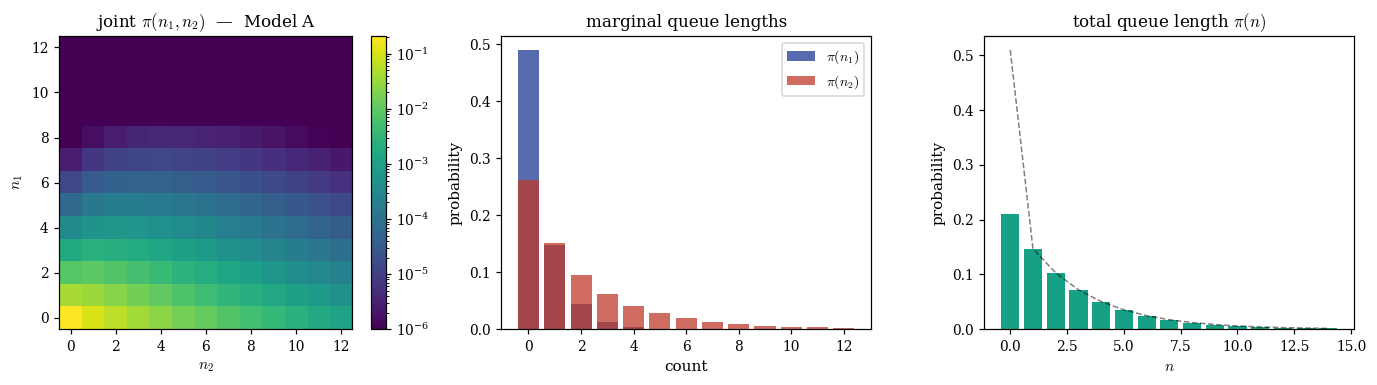

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
im = joint_heatmap(axes[0], res_A["pi_joint"], r"joint $\pi(n_1, n_2)$  —  Model A", log=True)
plt.colorbar(im, ax=axes[0], fraction=0.046)

m = marginals(res_A["pi_joint"])
marginal_bar(axes[1], m["pi_n1"], r"$\pi(n_1)$", "#1f3a93")
marginal_bar(axes[1], m["pi_n2"], r"$\pi(n_2)$", "#c0392b")
axes[1].set_title("marginal queue lengths")
axes[1].legend()

axes[2].bar(np.arange(15), m["pi_n"][:15], color="#16a085")
nn = np.arange(15)
axes[2].plot(nn, (1-rho)*rho**(nn+1) * (nn>=0) + (1-rho)*(nn==0),
             "k--", lw=1, alpha=0.5)
# theoretical: P(N=0) = pi(0,0) = rho(1-rho); P(N=n>=1) = (1-rho) rho^{n+1}? Recall N=n1+n2 queue.
# Actually full marginal of N including idle. Let's just show the queue-conditional.
axes[2].set_title(r"total queue length $\pi(n)$")
axes[2].set_xlabel(r"$n$"); axes[2].set_ylabel("probability")
fig.tight_layout()

The joint heatmap (log-scale) shows the asymmetry imposed by non-preemptive
priority: probability mass piles up on the $n_1 = 0$ row because class-1
customers are served immediately while class-2 customers accumulate.
$\mathbb{E}[N_1] \ll \mathbb{E}[N_2]$ at fixed offered load.


## 3. Model B — adding jockeying

$$\gamma_1, \gamma_2 \geq 0, \quad \theta_1 = \theta_2 = 0.$$

The interior balance gets two extra terms:
$$
+\,\gamma_1(n_1{+}1)\pi(n_1{+}1, n_2{-}1)\quad\text{(class-1 jockeys to class-2)},
$$
$$
+\,\gamma_2(n_2{+}1)\pi(n_1{-}1, n_2{+}1)\quad\text{(class-2 jockeys to class-1)}.
$$

**Important invariant.** Jockeying conserves the total queue count $n = n_1+n_2$.
Hence the marginal distribution of $N$ — and therefore $\mathbb{E}[N]$ — is the
same as the M/M/1 result $\rho^2/(1-\rho)$ for *any* $(\gamma_1, \gamma_2)$.
What jockeying changes is how that total is partitioned between the two classes.


In [4]:
p_B = Params(lam1=0.3, lam2=0.4, mu=1.0, gamma1=0.5, gamma2=0.3)
res_B = solve_exact(p_B, N_max=40)
d_B = diagnostics(p_B, res_B["pi_idle"], res_B["pi_joint"])

print(p_B.label())
print(f"  E[N]   exact   = {d_B['E_n']:.4f}   (must match Model A: {p_B.rho**2/(1-p_B.rho):.4f})")
print(f"  E[N_1] exact   = {d_B['E_n1']:.4f}   (Model A had {res_A['pi_joint'].sum(axis=1).dot(np.arange(41)):.4f})")
print(f"  E[N_2] exact   = {d_B['E_n2']:.4f}")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$, $\gamma_1=0.5$, $\gamma_2=0.3$
  E[N]   exact   = 1.6333   (must match Model A: 1.6333)
  E[N_1] exact   = 0.5149   (Model A had 0.3000)
  E[N_2] exact   = 1.1184


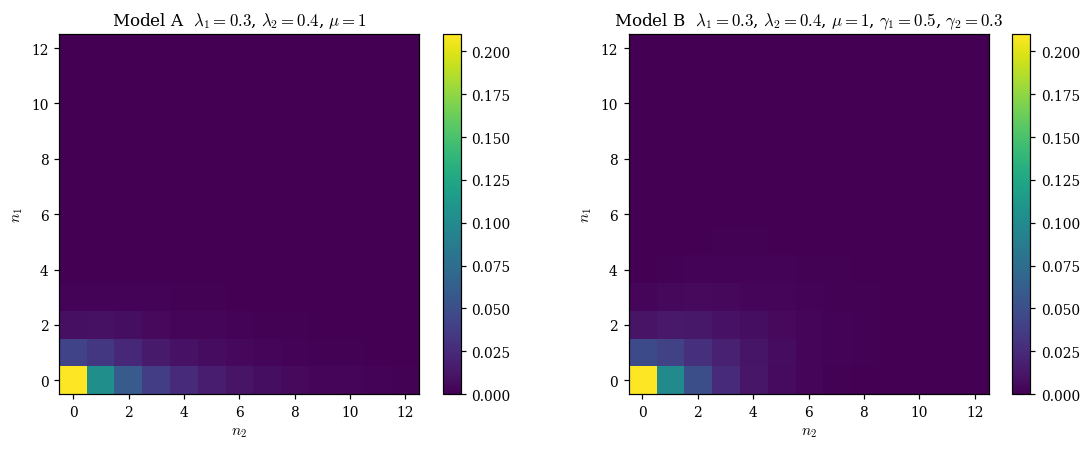

In [5]:
# Side-by-side joint heatmaps: Model A vs Model B
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
vmax = max(res_A["pi_joint"][:13, :13].max(), res_B["pi_joint"][:13, :13].max())
im0 = joint_heatmap(axes[0], res_A["pi_joint"], "Model A  " + p_A.label(),
                    vmin=0, vmax=vmax)
im1 = joint_heatmap(axes[1], res_B["pi_joint"], "Model B  " + p_B.label(),
                    vmin=0, vmax=vmax)
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()

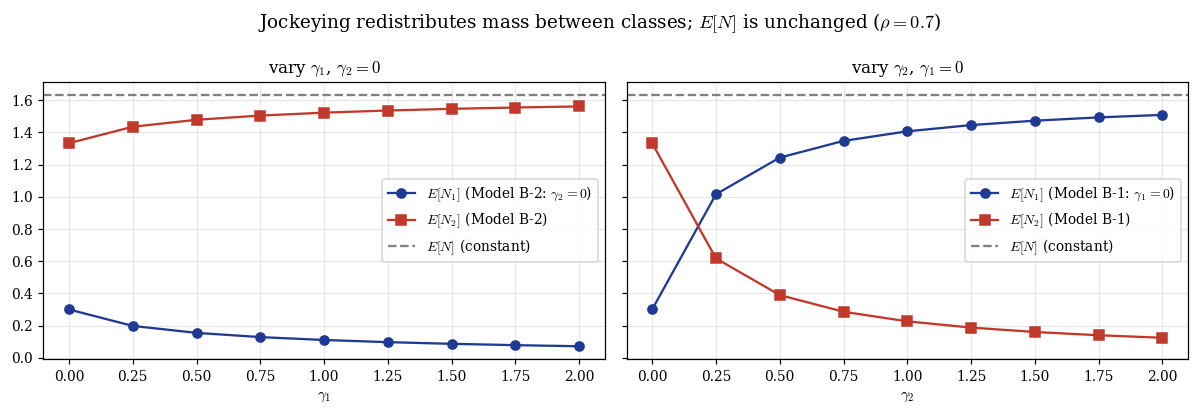

In [6]:
# Sweep gamma1 (with gamma2 = 0) and gamma2 (with gamma1 = 0) — show E[N_i] vs gamma.
gammas = np.linspace(0.0, 2.0, 9)
EN1_g1 = np.zeros_like(gammas); EN2_g1 = np.zeros_like(gammas)
EN1_g2 = np.zeros_like(gammas); EN2_g2 = np.zeros_like(gammas)
EN_g = np.zeros_like(gammas)

for k, g in enumerate(gammas):
    p1 = Params(0.3, 0.4, 1.0, gamma1=g, gamma2=0.0)
    p2 = Params(0.3, 0.4, 1.0, gamma1=0.0, gamma2=g)
    r1 = solve_exact(p1, N_max=40); d1 = diagnostics(p1, r1["pi_idle"], r1["pi_joint"])
    r2 = solve_exact(p2, N_max=40); d2 = diagnostics(p2, r2["pi_idle"], r2["pi_joint"])
    EN1_g1[k], EN2_g1[k] = d1["E_n1"], d1["E_n2"]
    EN1_g2[k], EN2_g2[k] = d2["E_n1"], d2["E_n2"]
    EN_g[k] = d1["E_n"]   # equals d2['E_n'] (both same rho)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
axes[0].plot(gammas, EN1_g1, "o-", label=r"$E[N_1]$ (Model B-2: $\gamma_2{=}0$)", color="#1f3a93")
axes[0].plot(gammas, EN2_g1, "s-", label=r"$E[N_2]$ (Model B-2)", color="#c0392b")
axes[0].axhline(EN_g[0], ls="--", color="grey", label=r"$E[N]$ (constant)")
axes[0].set_xlabel(r"$\gamma_1$"); axes[0].set_title(r"vary $\gamma_1$, $\gamma_2{=}0$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(gammas, EN1_g2, "o-", label=r"$E[N_1]$ (Model B-1: $\gamma_1{=}0$)", color="#1f3a93")
axes[1].plot(gammas, EN2_g2, "s-", label=r"$E[N_2]$ (Model B-1)", color="#c0392b")
axes[1].axhline(EN_g[0], ls="--", color="grey", label=r"$E[N]$ (constant)")
axes[1].set_xlabel(r"$\gamma_2$"); axes[1].set_title(r"vary $\gamma_2$, $\gamma_1{=}0$")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(r"Jockeying redistributes mass between classes; $E[N]$ is unchanged ($\rho{=}0.7$)")
fig.tight_layout()

**Read.** In Model B-2 ($\gamma_2 = 0$), only class-1 customers jockey — they
flee the empty priority queue toward class-2 at rate $\gamma_1 n_1$. Since
$\mathbb{E}[N_1] \ll \mathbb{E}[N_2]$ to begin with, even a modest $\gamma_1$
already pushes the few priority customers over to class-2: $\mathbb{E}[N_1]$
falls slowly while $\mathbb{E}[N_2]$ rises slowly.

In Model B-1 ($\gamma_1 = 0$) the picture is reversed and more dramatic:
class-2 customers — of which there are many — flee toward class-1 at rate
$\gamma_2 n_2$. As $\gamma_2$ grows the two classes equilibrate; in the limit
$\gamma_2 \to \infty$ the priorities are effectively erased and both classes
share $\mathbb{E}[N]/2$.


## 4. Variants B-1 ($\gamma_1=0$) and B-2 ($\gamma_2=0$) — side by side

These two variants are the analytically tractable special cases highlighted in
the thesis (see §6.1.1 and §6.1.2). For both we examine the joint distribution
and the marginal of the *non-jockeying* class to see how it shifts away from
the Model A baseline.


  Model B-1: E[N_1]=1.362  E[N_2]=0.271  E[N]=1.633
  Model B-2: E[N_1]=0.124  E[N_2]=1.509  E[N]=1.633


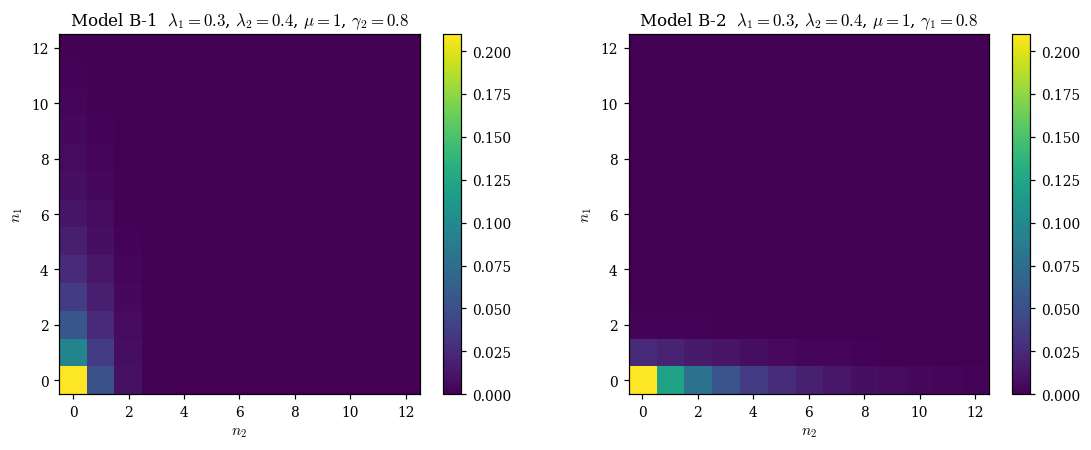

In [7]:
p_B1 = model_B1(0.3, 0.4, 1.0, gamma2=0.8)   # only class-2 jockeys (toward class-1)
p_B2 = model_B2(0.3, 0.4, 1.0, gamma1=0.8)   # only class-1 jockeys (toward class-2)

r_B1 = solve_exact(p_B1, N_max=40)
r_B2 = solve_exact(p_B2, N_max=40)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
vmax = max(r_B1["pi_joint"][:13, :13].max(), r_B2["pi_joint"][:13, :13].max())
im0 = joint_heatmap(axes[0], r_B1["pi_joint"], "Model B-1  " + p_B1.label(), vmin=0, vmax=vmax)
im1 = joint_heatmap(axes[1], r_B2["pi_joint"], "Model B-2  " + p_B2.label(), vmin=0, vmax=vmax)
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()

# numerical comparison
for name, p, r in [("B-1", p_B1, r_B1), ("B-2", p_B2, r_B2)]:
    d = diagnostics(p, r["pi_idle"], r["pi_joint"])
    print(f"  Model {name}: E[N_1]={d['E_n1']:.3f}  E[N_2]={d['E_n2']:.3f}  E[N]={d['E_n']:.3f}")

## 5. Models with abandonments — $\theta_1, \theta_2 \geq 0$

Two new transitions:
$$
+\,\theta_1(n_1{+}1)\pi(n_1{+}1,n_2)\quad\text{(class-1 abandons)},
$$
$$
+\,\theta_2(n_2{+}1)\pi(n_1,n_2{+}1)\quad\text{(class-2 abandons)}.
$$

Two qualitative facts to verify numerically:

1. **Flow conservation.** In steady state every arriving customer either
completes service or abandons:
$$\lambda_1+\lambda_2 = \mu\,\mathbb{P}(\text{busy}) + \theta_1\,\mathbb{E}[N_1]+\theta_2\,\mathbb{E}[N_2].$$
2. **Stability for arbitrary load.** Even $\rho > 1$ is positive recurrent when
at least one $\theta_i > 0$ (provided the class with the offending load is the
one that abandons).


In [8]:
# Demonstrate flow conservation across a range of theta.
p_T = Params(0.3, 0.4, 1.0, theta1=0.25, theta2=0.10)
r_T = solve_exact(p_T, N_max=40)
d_T = diagnostics(p_T, r_T["pi_idle"], r_T["pi_joint"])

print(p_T.label())
print(f"  E[N_1]   = {d_T['E_n1']:.4f}    E[N_2]   = {d_T['E_n2']:.4f}")
print(f"  throughput     = {d_T['throughput']:.4f}")
print(f"  abandonment    = {d_T['abandonment_rate']:.4f}")
print(f"  sum            = {d_T['carried_plus_lost']:.4f}")
print(f"  offered load   = {d_T['offered_load']:.4f}      (must match)")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$, $\theta_1=0.25$, $\theta_2=0.1$
  E[N_1]   = 0.1723    E[N_2]   = 0.4689
  throughput     = 0.6100
  abandonment    = 0.0900
  sum            = 0.7000
  offered load   = 0.7000      (must match)


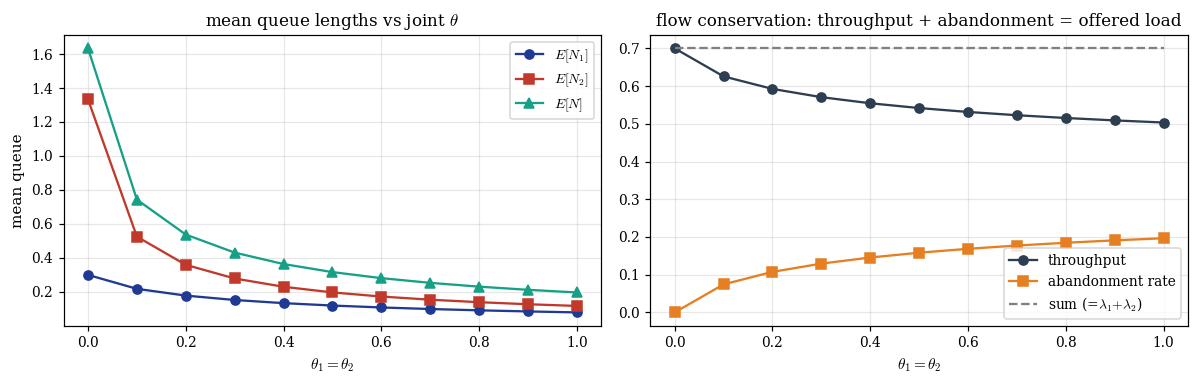

In [9]:
# Sweep theta = theta1 = theta2 jointly, watch the abandonment fraction.
thetas = np.linspace(0.0, 1.0, 11)
EN1, EN2, EN = np.zeros_like(thetas), np.zeros_like(thetas), np.zeros_like(thetas)
thru, aban = np.zeros_like(thetas), np.zeros_like(thetas)
for k, th in enumerate(thetas):
    p = Params(0.3, 0.4, 1.0, theta1=th, theta2=th)
    r = solve_exact(p, N_max=40)
    d = diagnostics(p, r["pi_idle"], r["pi_joint"])
    EN1[k], EN2[k], EN[k] = d["E_n1"], d["E_n2"], d["E_n"]
    thru[k], aban[k] = d["throughput"], d["abandonment_rate"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(thetas, EN1, "o-", color="#1f3a93", label=r"$E[N_1]$")
axes[0].plot(thetas, EN2, "s-", color="#c0392b", label=r"$E[N_2]$")
axes[0].plot(thetas, EN, "^-", color="#16a085", label=r"$E[N]$")
axes[0].set_xlabel(r"$\theta_1 = \theta_2$"); axes[0].set_ylabel("mean queue")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(r"mean queue lengths vs joint $\theta$")

axes[1].plot(thetas, thru, "o-", color="#2c3e50", label="throughput")
axes[1].plot(thetas, aban, "s-", color="#e67e22", label="abandonment rate")
axes[1].plot(thetas, thru + aban, "--", color="grey", label=r"sum (=$\lambda_1{+}\lambda_2$)")
axes[1].set_xlabel(r"$\theta_1 = \theta_2$")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("flow conservation: throughput + abandonment = offered load")
fig.tight_layout()

**Read.** Abandonments shorten both queues (small $\theta$ already removes most
of the slow class-2 mass). Flow conservation holds to machine precision —
throughput drops by exactly the abandonment loss.


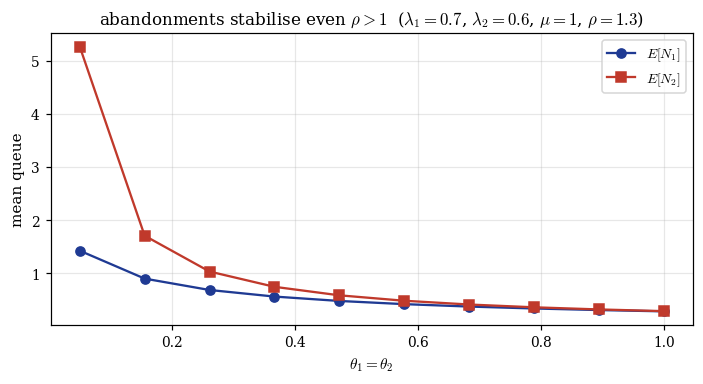

In [10]:
# Same scan, but with an UNSTABLE offered load rho > 1 stabilised by theta.
thetas = np.linspace(0.05, 1.0, 10)
EN1u, EN2u = np.zeros_like(thetas), np.zeros_like(thetas)
for k, th in enumerate(thetas):
    p = Params(0.7, 0.6, 1.0, theta1=th, theta2=th)   # rho = 1.3
    # Need larger truncation for very small theta (queues build up).
    Nmx = 60 if th < 0.2 else 40
    r = solve_exact(p, N_max=Nmx)
    d = diagnostics(p, r["pi_idle"], r["pi_joint"])
    EN1u[k], EN2u[k] = d["E_n1"], d["E_n2"]

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(thetas, EN1u, "o-", color="#1f3a93", label=r"$E[N_1]$")
ax.plot(thetas, EN2u, "s-", color="#c0392b", label=r"$E[N_2]$")
ax.set_xlabel(r"$\theta_1 = \theta_2$"); ax.set_ylabel("mean queue")
ax.set_title(r"abandonments stabilise even $\rho>1$  ($\lambda_1=0.7$, $\lambda_2=0.6$, $\mu=1$, $\rho=1.3$)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## 6. Special case — $\theta_1$ is the only non-zero parameter among $\{\gamma_1,\gamma_2,\theta_1,\theta_2\}$

$$\gamma_1 = \gamma_2 = \theta_2 = 0, \qquad \theta_1 > 0.$$

The priority class is impatient (abandons at rate $\theta_1$ per waiting
customer); the non-priority class is patient and there is no jockeying. The
interior balance simplifies to
$$
\bigl[\lambda_1+\lambda_2+\mu+\theta_1 n_1\bigr]\pi(n_1,n_2)
=\mu\pi(n_1{+}1,n_2)+\lambda_1\pi(n_1{-}1,n_2)+\lambda_2\pi(n_1,n_2{-}1)+\theta_1(n_1{+}1)\pi(n_1{+}1,n_2).
$$

This is an interesting middle ground: class-1 has the *negative* feedback of
abandonment but still has *positive* feedback through priority — when its
queue is non-empty, the server is dedicated to it. Two things we expect to see:

* **Class-1 marginal becomes light-tailed.** The geometric Model-A tail
$\pi(n_1)\propto\rho_1^{n_1}$ gives way to something closer to Poisson, because
the per-customer abandonment $n_1\theta_1$ dominates at large $n_1$.
* **Class-2 benefits.** Class-1 customers leave the system before they would
have been served, so the *effective* class-1 traffic that competes with class-2
is reduced. We should observe $\mathbb{E}[N_2]$ decreasing in $\theta_1$.


In [11]:
# Side-by-side: Model A vs theta_1-only
p_S = model_theta1_only(0.3, 0.4, 1.0, theta1=0.4)
r_S = solve_exact(p_S, N_max=40)
sim_S = simulate(p_S, n_events=500_000, max_n=40, seed=22)

d_A_local = diagnostics(p_A, res_A["pi_idle"], res_A["pi_joint"])
d_S       = diagnostics(p_S, r_S["pi_idle"], r_S["pi_joint"])
d_S_sim   = diagnostics(p_S, sim_S["pi_idle"], sim_S["pi_joint"])

print("Model A:                 ", p_A.label())
print(f"  E[N_1]={d_A_local['E_n1']:.3f}, E[N_2]={d_A_local['E_n2']:.3f}, throughput={d_A_local['throughput']:.3f}")
print("theta_1-only:            ", p_S.label())
print(f"  E[N_1]={d_S['E_n1']:.3f}, E[N_2]={d_S['E_n2']:.3f}, throughput={d_S['throughput']:.3f}, aban={d_S['abandonment_rate']:.3f}")
print(f"  (sim) E[N_1]={d_S_sim['E_n1']:.3f}, E[N_2]={d_S_sim['E_n2']:.3f}")

Model A:                  $\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$
  E[N_1]=0.300, E[N_2]=1.333, throughput=0.700
theta_1-only:             $\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$, $\theta_1=0.4$
  E[N_1]=0.154, E[N_2]=0.745, throughput=0.638, aban=0.062
  (sim) E[N_1]=0.153, E[N_2]=0.726


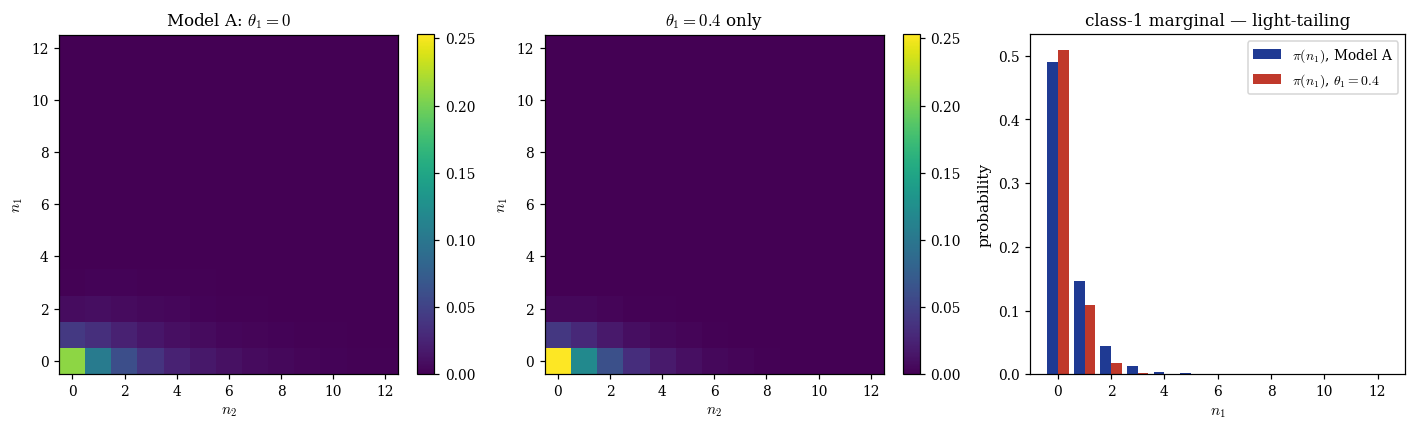

In [12]:
# Joint heatmaps + class-1 marginals overlay
fig = plt.figure(figsize=(13, 4.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])

ax0 = fig.add_subplot(gs[0])
vmax = max(res_A["pi_joint"][:13, :13].max(), r_S["pi_joint"][:13, :13].max())
im0 = joint_heatmap(ax0, res_A["pi_joint"], r"Model A: $\theta_1=0$", vmin=0, vmax=vmax)
plt.colorbar(im0, ax=ax0, fraction=0.046)

ax1 = fig.add_subplot(gs[1])
im1 = joint_heatmap(ax1, r_S["pi_joint"], rf"$\theta_1=0.4$ only", vmin=0, vmax=vmax)
plt.colorbar(im1, ax=ax1, fraction=0.046)

ax2 = fig.add_subplot(gs[2])
mA = marginals(res_A["pi_joint"])
mS = marginals(r_S["pi_joint"])
k = np.arange(13)
w = 0.4
ax2.bar(k - w/2, mA["pi_n1"][:13], width=w, color="#1f3a93",
        label=r"$\pi(n_1)$, Model A")
ax2.bar(k + w/2, mS["pi_n1"][:13], width=w, color="#c0392b",
        label=rf"$\pi(n_1)$, $\theta_1=0.4$")
ax2.set_xlabel(r"$n_1$"); ax2.set_ylabel("probability")
ax2.set_title("class-1 marginal — light-tailing")
ax2.legend()
fig.tight_layout()

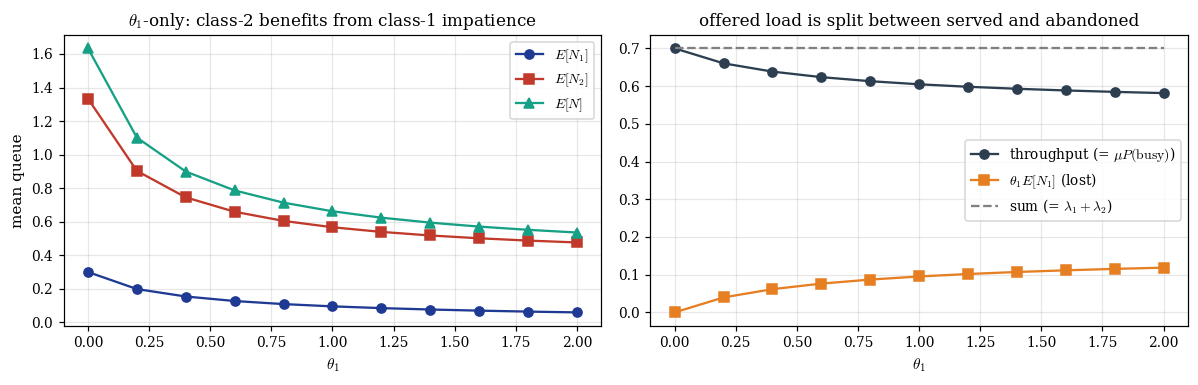

In [13]:
# Class-1 sweep: how E[N_1], E[N_2], throughput change with theta_1
thetas = np.linspace(0.0, 2.0, 11)
EN1, EN2, EN = np.zeros_like(thetas), np.zeros_like(thetas), np.zeros_like(thetas)
thru, aban = np.zeros_like(thetas), np.zeros_like(thetas)

for k, th in enumerate(thetas):
    p = Params(0.3, 0.4, 1.0, theta1=th)
    r = solve_exact(p, N_max=40)
    d = diagnostics(p, r["pi_idle"], r["pi_joint"])
    EN1[k], EN2[k], EN[k] = d["E_n1"], d["E_n2"], d["E_n"]
    thru[k], aban[k] = d["throughput"], d["abandonment_rate"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(thetas, EN1, "o-", color="#1f3a93", label=r"$E[N_1]$")
axes[0].plot(thetas, EN2, "s-", color="#c0392b", label=r"$E[N_2]$")
axes[0].plot(thetas, EN, "^-", color="#16a085", label=r"$E[N]$")
axes[0].set_xlabel(r"$\theta_1$"); axes[0].set_ylabel("mean queue")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title(r"$\theta_1$-only: class-2 benefits from class-1 impatience")

axes[1].plot(thetas, thru, "o-", color="#2c3e50", label="throughput (= $\\mu P(\\text{busy})$)")
axes[1].plot(thetas, aban, "s-", color="#e67e22", label=r"$\theta_1 E[N_1]$ (lost)")
axes[1].plot(thetas, thru + aban, "--", color="grey",
             label=r"sum (= $\lambda_1+\lambda_2$)")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("offered load is split between served and abandoned")
fig.tight_layout()

**Read.** As $\theta_1$ grows from zero the priority class becomes increasingly
impatient. Two coupled effects:

* $\mathbb{E}[N_1]$ falls — the direct effect of the abandonment "drain".
* $\mathbb{E}[N_2]$ falls *too* — class-2 sees fewer class-1 customers to wait
  behind, even though $\lambda_2$ and $\mu$ are unchanged. The priority
  mechanism is mechanically weakened.

The total $\mathbb{E}[N]$ decreases monotonically with $\theta_1$. In the
opposite direction, $\theta_1 \to 0$ recovers Model A.

The throughput / abandonment plot makes the budget visible: at $\theta_1=2.0$,
roughly a quarter of the priority class is lost rather than served.


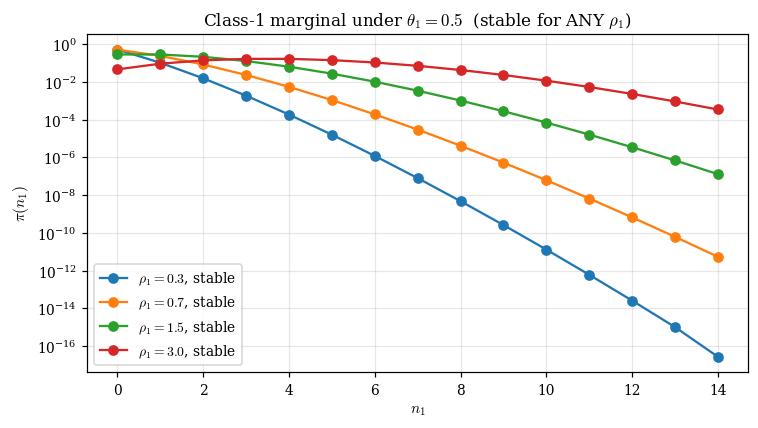

In [14]:
# Bonus: show that this configuration is stable for arbitrarily large rho_1,
# as long as rho_2 < 1.
rhos1 = np.array([0.3, 0.7, 1.5, 3.0])
lam2_fix = 0.4
mu = 1.0
theta1 = 0.5

fig, ax = plt.subplots(figsize=(7, 4))
for r1 in rhos1:
    p = Params(r1*mu, lam2_fix, mu, theta1=theta1)
    Nmx = 60
    r = solve_exact(p, N_max=Nmx)
    pi_n1 = r["pi_joint"].sum(axis=1)
    n1s = np.arange(15)
    ax.plot(n1s, pi_n1[:15], "o-",
            label=rf"$\rho_1={r1}$, stable" if r1 + lam2_fix/mu < 1 or theta1 > 0 else f"$\\rho_1={r1}$")
ax.set_xlabel(r"$n_1$"); ax.set_ylabel(r"$\pi(n_1)$")
ax.set_title(rf"Class-1 marginal under $\theta_1={theta1}$  (stable for ANY $\rho_1$)")
ax.set_yscale("log")
ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

## 7. Cross-model comparison

Putting Model A, Model B, the full abandonment model, and the $\theta_1$-only
special case side by side at the same offered load.


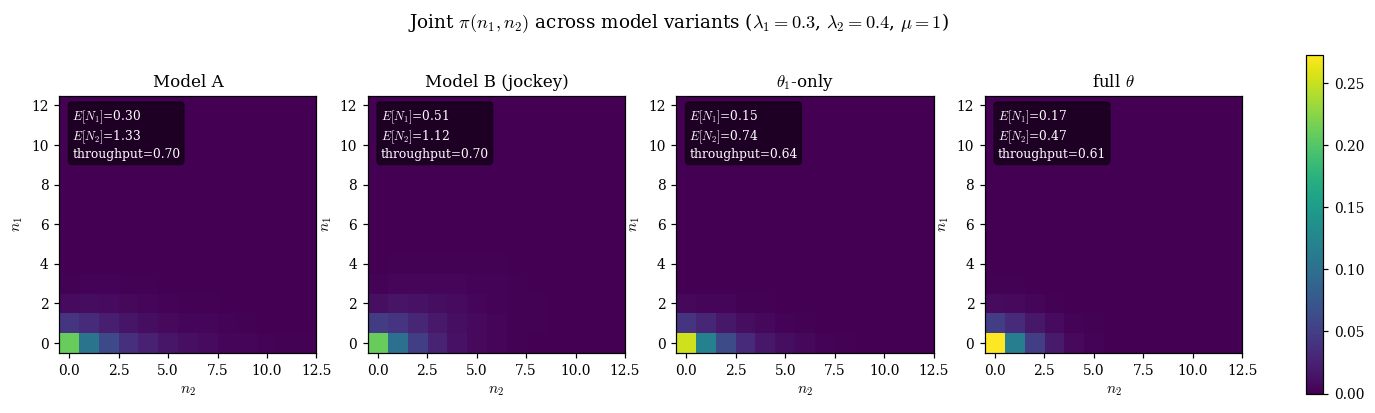

model                    E[N_1]   E[N_2]     E[N]   throughput      aban
Model A                   0.300    1.333    1.633       0.7000    0.0000
Model B (jockey)          0.515    1.118    1.633       0.7000    0.0000
$\theta_1$-only           0.154    0.745    0.899       0.6384    0.0616
full $\theta$             0.172    0.469    0.641       0.6100    0.0900


In [15]:
base = dict(lam1=0.3, lam2=0.4, mu=1.0)
scenarios = [
    ("Model A",            Params(**base)),
    ("Model B (jockey)",   Params(**base, gamma1=0.5, gamma2=0.3)),
    (r"$\theta_1$-only",   Params(**base, theta1=0.4)),
    (r"full $\theta$",     Params(**base, theta1=0.25, theta2=0.10)),
]

fig, axes = plt.subplots(1, 4, figsize=(15.0, 4.0))
vmax = max(solve_exact(p, N_max=30)["pi_joint"][:13, :13].max() for _, p in scenarios)
results = []
for ax, (name, p) in zip(axes, scenarios):
    r = solve_exact(p, N_max=40)
    d = diagnostics(p, r["pi_idle"], r["pi_joint"])
    im = joint_heatmap(ax, r["pi_joint"], name, vmin=0, vmax=vmax)
    ax.text(0.05, 0.95,
            f"$E[N_1]$={d['E_n1']:.2f}\n$E[N_2]$={d['E_n2']:.2f}\nthroughput={d['throughput']:.2f}",
            transform=ax.transAxes, va="top", ha="left",
            color="white", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="black", alpha=0.55))
    results.append((name, d))
fig.colorbar(im, ax=axes, fraction=0.025)
fig.suptitle(r"Joint $\pi(n_1, n_2)$ across model variants ($\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$)")
plt.show()

# Tabulate
print(f"{'model':<22s} {'E[N_1]':>8s} {'E[N_2]':>8s} {'E[N]':>8s} {'throughput':>12s}  {'aban':>8s}")
for name, d in results:
    print(f"{name:<22s} {d['E_n1']:>8.3f} {d['E_n2']:>8.3f} {d['E_n']:>8.3f} {d['throughput']:>12.4f}  {d['abandonment_rate']:>8.4f}")

This is the "one-glance" comparison: at the same load $\rho = 0.7$, each
variant arranges the joint distribution differently.

* Model A concentrates mass on the $n_1 = 0$ axis (priority class is short);
* jockeying smears mass diagonally;
* $\theta_1$-only pulls the marginal of $n_1$ back toward zero *and* shortens
  the class-2 tail;
* full abandonments shrink everything.

Same numerical pattern repeats: $E[N]$ is invariant under jockeying, but any
$\theta_i > 0$ trades served customers for abandoned ones according to the
balance $\lambda_1+\lambda_2 = \mu P(\text{busy}) + \theta_1 E[N_1] + \theta_2 E[N_2]$.
